# YOLO(You Only Look Once)

### **YOLO confidence 계산 원리**
YOLO는 한 개의 박스(box)에 대해 크게 두 가지를 예측한다:
1) Objectness Score :  이 박스 안에 “물체가 있을 확률”.  범위: 0 ~ 1<br>
   예: 0.9 → 90% 확률로 뭔가 물체가 있음
2) Class Probability Distribution :  그 물체가 어떤 클래스인지의 확률 분포
   softmax나 sigmoid를 통해 각 클래스별 확률을 출력<br>
   예: {dog: 0.8, cat: 0.15, person: 0.05}

- 최종 Confidence 수식
 YOLO는 특정 클래스 c에 대해 Confidenc
 (box, c) = P(object) × P(class=c ∣ object)
 즉, 물체가 있음 확률 × 그 물체가 특정 클래스일 확률로 계산한다.

예)
- Objectness = 0.9,
- Class probabilities = {dog: 0.8, cat: 0.15, person: 0.05}

dog 클래스의 confidence는 0.9×0.8=0.72
     따라서 출력은  dog: 0.72,  cat: 0.135,  person: 0.045

훈련 과정에서
  - 정답(GT) 박스와 예측 박스를 IoU로 비교해서 Positive / Negative 결정
  - Loss 함수에 objectness loss + classification loss + localization loss가 모두 들어감
  - objectness는 IoU를 기반으로 라벨링되므로, 결국 학습하면서 “confidence가 IoU에 비례하도록” 학습됨

간단히 말해 YOLO의 **confidence = Objectness × Class probability**로 계산한다.
  - objectness → 이 위치에 물체가 있을 가능성
  - class prob → 그것이 특정 클래스일 가능성
  이 두 개를 곱해 최종 confidence가 출력됨

In [6]:
# # Colab에서 YOLO설치 하기

# 프로그램상 설치하는 방법
# import subprocess
# import sys
# try:
#   from ultralytics import YOLO
# except ModuleNotFoundError:
#   print('ultralytiscs가 설치 되지 않음')
#   try:
#     subprocess.call([sys.executable, '-m', 'pip', 'install', 'ultralytics','opencv-python'])
#   except subprocess.CalledProcessError as e:
#     raise SystemExit(f'ultralytiscs 설치 실패 : {e}')
#     from ultralytics import YOLO

# 간편버전
!pip install ultralytics opencv-python

In [7]:
import ultralytics
ultralytics.checks() # 8.4.51

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.5/107.7 GB disk)


In [10]:
# YOLO11모델로 이미지 감지
from ultralytics import YOLO
import ultralytics

print(ultralytics.__version__) # 8.4.51
model = YOLO('yolo11n.pt') # nano version, s, m, l .. 등의 버전이 있다.
print(model.names, len(model.names)) # COCO dataset으로 학습된 모델이므로 라벨 80개가 있다.

8.4.51
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 

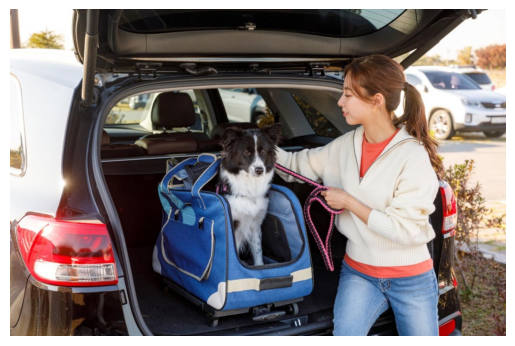


0: 448x640 1 person, 2 cars, 1 dog, 293.2ms
Speed: 19.3ms preprocess, 293.2ms inference, 14.2ms postprocess per image at shape (1, 3, 448, 640)
(636, 966)
image.shape :  (636, 966, 3)
image[0, 0] :  [187 165 152]


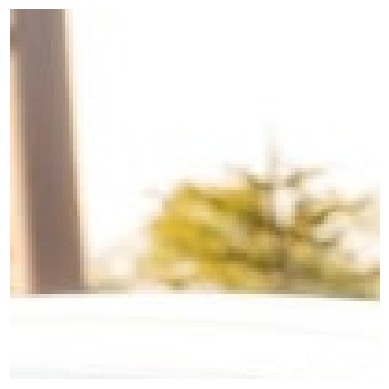

In [38]:
# 이미지 로딩 후 감지
from PIL import Image
import matplotlib.pyplot as plt
import sys

# image_path = '/content/drive/MyDrive/yolo_imgs/dog.jpg' # test할 이미지 경로
image_path = 'image.jpeg' # test할 이미지 경로
try:
  image = Image.open(image_path)
  plt.imshow(image)
  plt.axis('off')
  plt.show()
except Exception as e:
  print('load err', e)
  sys.exit()

# 객체 감지
import cv2
import numpy as np

try:
  # results = model(image)
  results = model(image, conf=0.25) # 신뢰확률 미리 정하기.
  # print(result)
  print(results[0].orig_shape) # (183, 275) # 강아지가 두마리여도 result[0]번째에 있다.
except Exception as e:
  print('inference err', e)
  sys.exit()


# Pillow이미지 -> image.open() -> np.array()하면 (H, W, C=3)형태의 넘파이 배열이 됨
image = np.array(image)
print('image.shape : ', image.shape) # image.shape :  (183, 275, 3)
# print('image[:5, :5] : ', image[:5, :5])
print('image[0, 0] : ', image[0, 0])

# 이미지 영역 자르기
cropped = image[:100, :100]
plt.imshow(cropped)
plt.axis('off')
plt.show()

510 84 847 628
person
box.conf[0] : tensor(0.8708)
confidence :  0.8708081245422363
398 224 529 497
dog
box.conf[0] : tensor(0.8168)
confidence :  0.8168142437934875
768 112 965 256
car
box.conf[0] : tensor(0.7923)
confidence :  0.7922823429107666
5 1 940 617
car
box.conf[0] : tensor(0.5702)
confidence :  0.5701820254325867
dog_detected : True


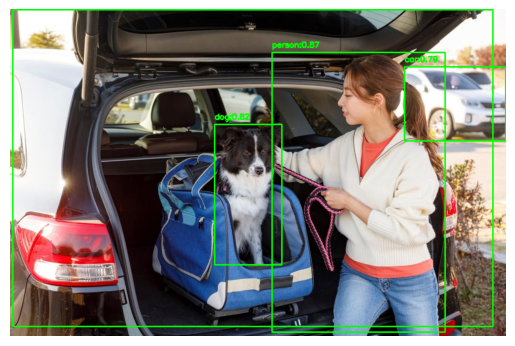

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# dog 이미지에 박스 채우기
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

dog_detected = False # dog 감지 여부 판단용 함수

for result in results:

  try:
    for box in result.boxes: # 감지된 객체들의 바운딩 박스 리스트
      # 바운딩 좌표, label 얻기
      x1, y1, x2, y2 = map(int, box.xyxy[0])  # 바운딩 박스 좌표 반환
      label = result.names[int(box.cls[0])]   # 감지된 객체 클래스 이름 얻기
      print(x1, y1, x2, y2)
      print(label)
      # 11 21 134 151
      # dog
      # 141 22 261 149
      # dog

      # 신뢰도 확인하기
      print('box.conf[0] :', box.conf[0]) # box.conf[0] : tensor(0.5285)
      confidence = box.conf[0].item() # 신뢰도 : 바운딩 박스 안에 해당 클래스가 실제로 있을 확률 값
      print('confidence : ',confidence) # 0.52848756

      if label == 'dog' and confidence > 0.4: # 실제로는 0.2~0.3, 엄격하게 하면 0.4
        dog_detected = True

      # 바운딩 박스 그리기
      cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
      cv2.putText(image, f'{label}:{confidence:.2f}', (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

  except Exception as e:
    print(f'process err : {e}')

print("dog_detected :", dog_detected)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

if label == 'dog' and confidence > 0.4:
  print('dog detected')

# 감지 결과 파일로 저장
cv2.imwrite('yolo1out.jpg', image)

# colab에서 저장한 이미지 다운로드할 경우
from google.colab import files
files.download('yolo1out.jpg')